In [1]:
import os
import sys

sys.path.append("../")

envkey = "OMP_NUM_THREADS"
# Set this environment variable to the number of available cores in your machine,
# to get a fast execution of the Einstein Boltzmann Solver
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))
os.environ[envkey] = str(12)
print("The value of {:s} is: ".format(envkey), os.environ.get(envkey))

The value of OMP_NUM_THREADS is:  None
The value of OMP_NUM_THREADS is:  12


In [2]:
import astropy.units as u
import matplotlib.pyplot as plt
from copy import copy, deepcopy
import numpy as np
import seaborn
from getdist.gaussian_mixtures import GaussianND
from getdist import plots
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, RectBivariateSpline
from matplotlib import cm, colors
from matplotlib.ticker import LogLocator, FuncFormatter
import niceplots.utils as nicepl


nicepl.initPlot()
Cs = seaborn.color_palette("colorblind")
Cp = seaborn.color_palette("Paired")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [3]:
# Import Main modules. This might take some time as some functions compile before time
from SSLimPy.interface import sslimpy
from SSLimPy.cosmology import cosmology
from SSLimPy.cosmology import halo_model
from SSLimPy.cosmology import astro
from SSLimPy.LIMsurvey import covariance as scov
from SSLimPy.LIMsurvey import power_spectrum as spobs

In [4]:
settings = {
    "code":"class", # The Einstein--Boltzman solver that should be used
    "do_RSD" : False, # If RSD should be considerd
    "nonlinearRSD" : False, # If you want to add FOG to the RSD
    "QNLpowerspectrum": False, # Use dewiggled power spectrum (vlasov approximation of nonlinear structure formation)
    "FoG_damp" : "ISTF_like", # The particular parametrization for the FOG. Check PowerSpectrum for the full list
    "halo_model_PS" : True, # If the cosmological shotnoise should be computed from the halo model 
    "output" : ["Power spectrum", "Covariance"], # What output one wants (here power spectrum and Gaussian covariance only)
    "kmin": 1e-4 * u.Mpc**-1,
    "kmax": 50 * u.Mpc**-1,
    "nk": 200,
}

cosmodict={
    "h": 0.677,
    "Omegam": 0.309167,
    "Omegab": 0.04903,
    "sigma8":0.8222,
    "ns":0.96824,
    "mnu":0.06,
    "Neff":3.044,
}

# Parameters that enter your halo model. Typically they are not changed but you could
halodict={
    "halo_tracer" : "clustering", # Computes all halo quantities from the matter field - neutrinos
    "hmf_model": "ST", # Sheth--Tormann halo mass function
    "concentration": "Diemer19", # Diemer19 halo concentration relation
    "bias_model": "ST99",
}

# Parameters for the Survey specifications
z = np.array([1])
def get_specs(nu):
        nuObs = nu / (z + 1)
        DeltaDeltanu = 0.05143

        surveyspecs = {
                "Tsys_NEFD": 0 * u.uK, #System temperature for instrumental shotnoise
                "Nfeeds": 19,
                "tobs": 1300 * u.h,
                "nD": 1, # Observational parameters
                "beam_FWHM": 0. * u.arcmin,
                "nu":  nu,
                "nuObs": nuObs, # Observed Frequency
                "Delta_nu": DeltaDeltanu * nuObs, # Frequency Bin
                "dnu": 0. * u.MHz, # Spectrograph resolution
                "Omega_field": 18.64 * u.deg**2, # Angular size of survey
        }
        return surveyspecs

astrodict_CII={
    "model_type": "ML",
    "model_name": "SilvaCII",
    "model_par": {
        "a": 0.8475,
        "b": 7.2203,
        "SFR_file": "sfr_release.dat",
        "do_quench": False,
    },
    "sigma_scatter" : 0.37,
    "meanperserve_scatter": False,
}

nu = 1.897 * u.THz
surveyspecs_CII = get_specs(nu)

In [5]:
myssl = sslimpy.SSLimPy(
    settings_dict=settings,
    cosmopars=cosmodict,
    halopars=halodict,
    astropars=astrodict_CII,
    obspars_dict=surveyspecs_CII,
)

myastro = myssl.current_astro
mycosmo = myastro.cosmology
h = mycosmo.h()

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/sefa/Desktop/projects/LIM-Code/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


In [6]:
mycosmo.z

array([0.        , 0.16129032, 0.32258065, 0.48387097, 0.64516129,
       0.80645161, 0.96774194, 1.12903226, 1.29032258, 1.4516129 ,
       1.61290323, 1.77419355, 1.93548387, 2.09677419, 2.25806452,
       2.41935484, 2.58064516, 2.74193548, 2.90322581, 3.06451613,
       3.22580645, 3.38709677, 3.5483871 , 3.70967742, 3.87096774,
       4.03225806, 4.19354839, 4.35483871, 4.51612903, 4.67741935,
       4.83870968, 5.        ])

In [7]:
z = np.linspace(0, 5)
a = 1 / (1 + z)

D = mycosmo.growth_factor(1e-2 * u.Mpc**-1, z)

def linear(x, a, b):
    return a * x + b

curve_fit(linear, np.log(a), np.log(D))

(array([0.90609532, 0.10373684]),
 array([[6.10870217e-05, 6.99376189e-05],
        [6.99376189e-05, 9.48937955e-05]]))

In [8]:
myastro.Tavg(1, 1)

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<Quantity [0.23975671] uK>

In [9]:
pobs_CII = spobs.PowerSpectra(myastro)
ssc_cov = scov.SuperSampleCovariance(pobs_CII)

In [10]:
halo = myastro.halomodel

In [11]:
myastro.Tbavg(1, 1, 1), myastro.Tbavg("b1", 1, 1), 1.04 * 0.2284 * u.uK

(<Quantity 0.26903407 uK>, <Quantity 0.28836732 uK>, <Quantity 0.237536 uK>)

0.9729283783137482 0.310289 / Mpc3
0.9774285176813083 0.310289 / Mpc3
0.9939406314676689 0.310289 / Mpc3
1.0631234185726504 0.310289 / Mpc3


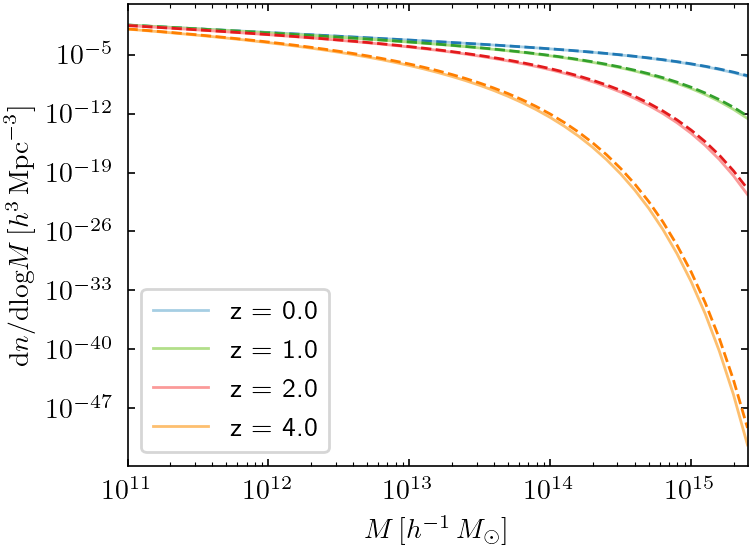

In [12]:
from colossus.cosmology import cosmology
cosmo_c = cosmology.setCosmology('planck18') # Roughly

from colossus.lss import mass_function

z = [0.0, 1.0, 2.0, 4.0]
M = 10**np.arange(11.0, 15.5, 0.1)

color = iter(Cp)
plt.figure()
plt.xlabel(r'$M\,[h^{-1}\,M_\odot]$')
plt.ylabel(r'$\mathrm{d}n/\mathrm{dlog}M\,[h^3\,\mathrm{Mpc}^{-3}]$')
plt.loglog()
for i in range(len(z)):
    c= next(color)
    mfunc = mass_function.massFunction(M, z[i], mdef = '200m', model = 'tinker08', q_out = 'dndlnM')
    plt.plot(M, mfunc, '-', label = 'z = %.1f' % (z[i]), c=c)

    c= next(color)
    mfunc_ssl = ((M * myastro.Msunh) * halo._halo_mass_function.Tinker(M * myastro.Msunh, z[i])).to(h**3 / u.Mpc**3)
    plt.plot(M, mfunc_ssl, c=c, ls="--")
    print(np.max(mfunc_ssl[0] / mfunc[0]))
plt.legend()

In [13]:
from scipy.stats import binned_statistic

<>:12: SyntaxWarning: invalid escape sequence '\G'
<>:12: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_28626/515130974.py:12: SyntaxWarning: invalid escape sequence '\G'
  for b, label in zip([b1, b2, b3, bG2, bDG2], ["$b_1$", "$b_2$", "$b_3$", r"$b_{\mathcal{G}_2}$", "$b_\Gamma$"]):
/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


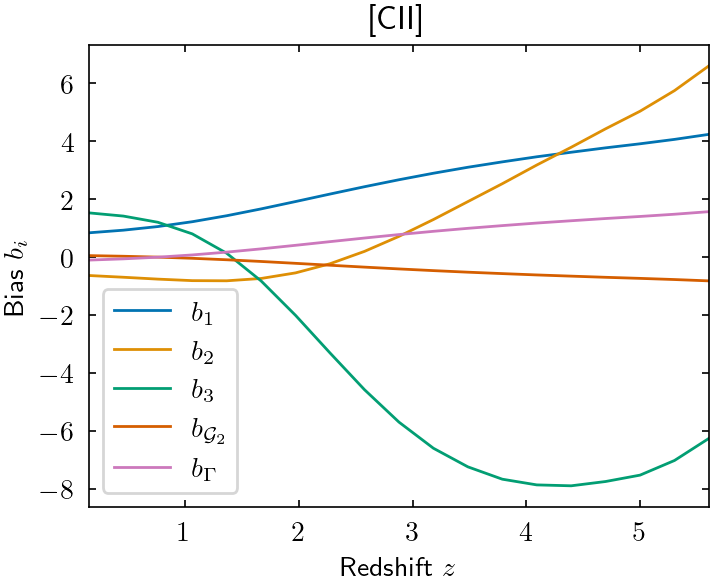

In [14]:
z = np.linspace(0, 6, 100)
b1 = myastro.bavg("b1", z, 1)
b2 = myastro.bavg("b2_fitted", z, 1)
b3 = myastro.bavg("b3", z, 1)
bG2 = myastro.bavg("bG2", z, 1)
bDG2 = myastro.bavg("bDG2", z, 1)

zinter = z[::5]
zmean = 0.5 * (zinter[1:] + zinter[:-1])

color = iter(Cs)
for b, label in zip([b1, b2, b3, bG2, bDG2], ["$b_1$", "$b_2$", "$b_3$", r"$b_{\mathcal{G}_2}$", "$b_\Gamma$"]):
    bbinned , _, _ = binned_statistic(z, b, "mean", zinter)
    plt.plot(zmean, bbinned, label=label, c=next(color))
plt.legend(loc="lower left")
plt.title("[CII]")
plt.xlabel("Redshift $z$")
plt.ylabel("Bias $b_i$")

plt.savefig("output/biasplot_v2.pdf")

<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:12: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:15: SyntaxWarning: invalid escape sequence '\,'
<>:19: SyntaxWarning: invalid escape sequence '\,'
<>:11: SyntaxWarning: invalid escape sequence '\,'
<>:12: SyntaxWarning: invalid escape sequence '\,'
<>:13: SyntaxWarning: invalid escape sequence '\,'
<>:15: SyntaxWarning: invalid escape sequence '\,'
<>:19: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_28626/4258193593.py:11: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(z, b1, c=next(color), label="$D\,b_1$")
/tmp/ipykernel_28626/4258193593.py:12: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(z, b2, c=next(color), label="$D^2\,b_2$")
/tmp/ipykernel_28626/4258193593.py:13: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(z, b3, c=next(color), label="$D^3\,b_3$")
/tmp/ipykernel_28626/4258193593.py:15: SyntaxWarning: invalid escape sequence '\,'
 

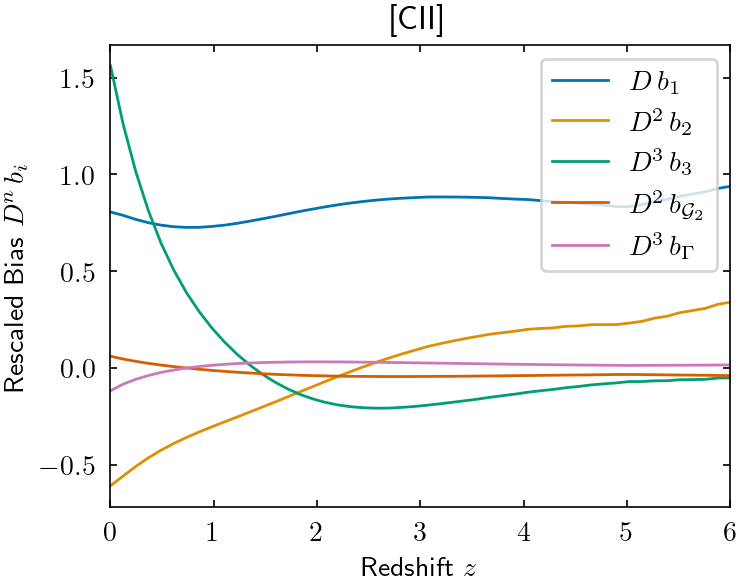

In [15]:
z = np.linspace(0, 6)
D = mycosmo.growth_factor(1e-4 * u.Mpc**-1, z)

b1 = myastro.bavg("b1", z, 1) * D
b2 = myastro.bavg("b2_fitted", z, 1) * D**2
b3 = myastro.bavg("b3", z, 1) * D**3
bG2 = myastro.bavg("bG2", z, 1) * D**2
bDG2 = myastro.bavg("bDG2", z, 1) * D**3

color = iter(Cs)
plt.plot(z, b1, c=next(color), label="$D\,b_1$")
plt.plot(z, b2, c=next(color), label="$D^2\,b_2$")
plt.plot(z, b3, c=next(color), label="$D^3\,b_3$")
plt.plot(z, bG2, c=next(color), label=r"$D^2\,b_{\mathcal{G}_2}$")
plt.plot(z, bDG2, c=next(color), label="$D^3\,b_\Gamma$")
plt.legend()
plt.title("[CII]")
plt.xlabel("Redshift $z$")
plt.ylabel("Rescaled Bias $D^n\,b_i$")

plt.savefig("output/biasplot_v1.pdf")

In [16]:
import matplotlib.patches as mpatches

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/tmp/ipykernel_28626/3344382694.py:7: RuntimeWarning: divide by zero encountered in divide
  return np.pi / k / 2


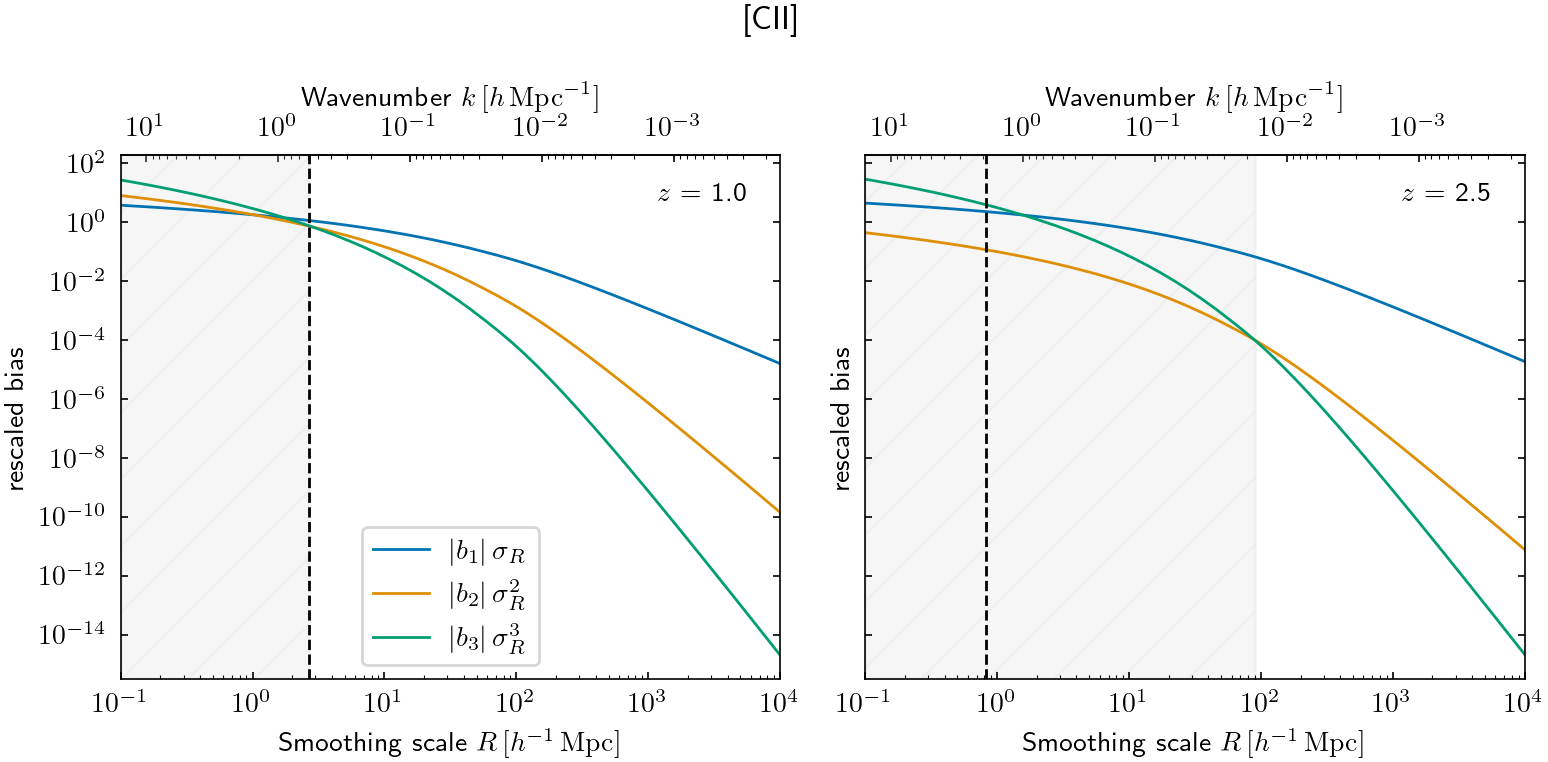

In [17]:
R = (np.geomspace(1e-1, 1e4) * myastro.Mpch).to(myastro.Mpch)

def R_to_k(R):
    return (np.pi / R / 2)

def k_to_R(k):
    return np.pi / k / 2

# Choose redshifts
z_values = [1.0, 2.5]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
color = iter(Cs)

for ax, z in zip(axes.flat, z_values):
    # Compute factors
    sigmaR1 = halo.sigmaR_of_z(R, z)
    b1 = np.abs(myastro.bavg("b1", z, power=1)) * sigmaR1**1
    b2 = np.abs(myastro.bavg("b2_fitted", z, power=1)) * sigmaR1**2
    b3 = np.abs(myastro.bavg("b3", z, power=1)) * sigmaR1**3

    #compute the R_NL
    Rnl = R[np.argmin(np.abs(sigmaR1-1))]
    Rperturb = R[np.argmin((b3 / b2 -1)**2)]
    
    # Reset colors for each subplot so curves stay consistent
    color_iter = iter(Cs)
    # Plot
    for b, l in zip(
        [b1, b2, b3],
        [r"$|b_1|\,\sigma_R$", r"$|b_2|\,\sigma_R^2$", r"$|b_3|\,\sigma_R^3$"]
    ):
        c = next(color_iter)
        ax.loglog(R, b, label=l, color=c)

    # Labels and secondary axis
    ax.set_xlabel(r"Smoothing scale $R\,[h^{-1}\,\mathrm{Mpc}]$")
    ax.set_ylabel(r"rescaled bias")
    ax.tick_params(axis="x", which="both", top=False)

    ax.axvspan(1e-1, Rperturb.value, color="lightgrey", alpha=0.2, hatch="/")
    ax.axvline(Rnl.value, ls="--", c="k")

    secax = ax.secondary_xaxis("top", functions=(R_to_k, k_to_R))
    secax.set_xlabel(r"Wavenumber $k\,[h\,\mathrm{Mpc}^{-1}]$")

    # Add z label inside subplot
    ax.text(0.95, 0.95, f"$z$ = {z}", transform=ax.transAxes,
            ha="right", va="top",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7))

# Legend only once (upper-left panel)
axes[0].legend()
plt.suptitle("[CII]")
plt.tight_layout()
plt.savefig("output/pertive_scale.pdf")

<>:22: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:22: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_28626/2312813321.py:22: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel("$k\,[h\,\mathrm{Mpc}^{-1}]$")
/tmp/ipykernel_28626/2312813321.py:23: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel("$P(k)\,[\mu \mathrm{K}^2 \,h^{-3}\,\mathrm{Mpc}^{3}]$")


Text(0, 0.5, '$P(k)\\,[\\mu \\mathrm{K}^2 \\,h^{-3}\\,\\mathrm{Mpc}^{3}]$')

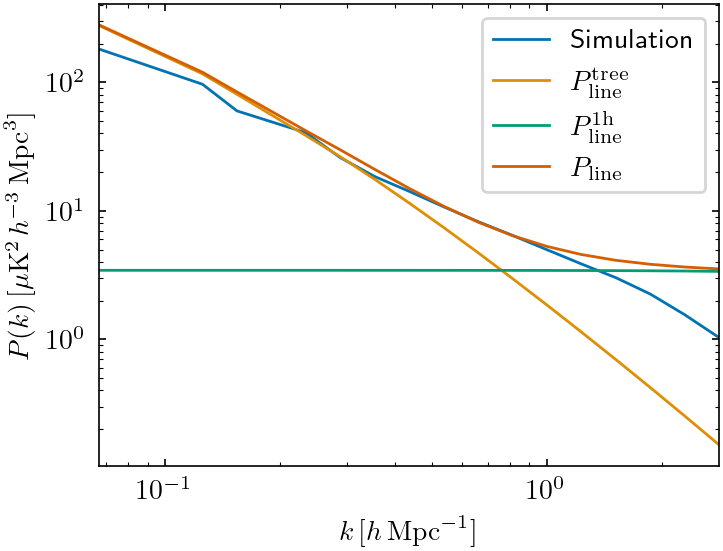

In [18]:
kpk = np.load("/home/sefa/Desktop/projects/LIM-Code/clusterdata/CII_A_438681_Response_NSUB8.npz")
k, Pk = kpk["k"], np.mean(kpk["Pkmean"], axis=0)

mask = ~np.isnan(Pk)
k, Pk = k[mask], Pk[mask]

kth = k * myastro.Mpch**-1
I11 = myastro.Thalo(1, kth, p=1, scale=(1,), beta=1)
I02 = myastro.Thalo(1, kth, p=1, scale=(2,), beta=0)

# I02 = np.ones_like(I02.value) * 3.29 * u.uK**2 * myastro.Mpch**3

plin = mycosmo.matpow(kth, 1)

color = iter(Cs)
plt.loglog(k, Pk, c=next(color), label="Simulation")
plt.loglog(k, (I11**2 * plin).to(myastro.Mpch**3 * u.uK**2), c=next(color), label=r"$P_\mathrm{line}^\mathrm{tree}$")
plt.loglog(k, (I02).to(myastro.Mpch**3 * u.uK**2), c=next(color), label=r"$P_\mathrm{line}^\mathrm{1h}$")
plt.loglog(k, (I11**2 * plin + I02).to(myastro.Mpch**3 * u.uK**2), c=next(color), label=r"$P_\mathrm{line}$")

plt.legend()
plt.xlabel("$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel("$P(k)\,[\mu \mathrm{K}^2 \,h^{-3}\,\mathrm{Mpc}^{3}]$")

# plt.savefig("output/powerspectra_CII_measurements.pdf")

In [19]:
from scipy.integrate import quad

In [20]:
def Weff(phi, mu, x):
    x1 = x * np.sqrt(1 - mu**2) * np.cos(phi)
    x2 = x * np.sqrt(1 - mu**2) * np.sin(phi)
    x3 = x * mu
    coords = np.array([x1, x2, x3])
    sincs = np.sinc(coords / 2 / np.pi)
    return np.prod(sincs**2)

def phi_integration(mu, x):
    result, _ = quad(Weff, -np.pi, np.pi, (mu, x))
    return result

def mu_integration(x):
    result, _ = quad(phi_integration, -1, 1, (x, ))
    return result

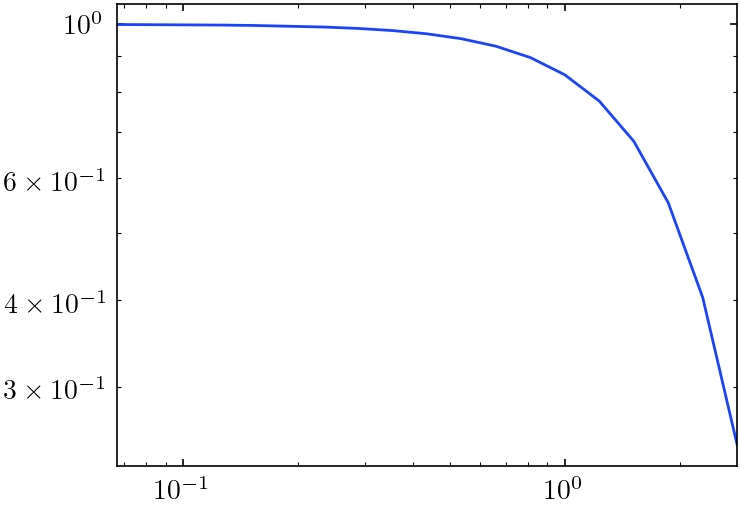

In [21]:
deltax = 1 * myastro.Mpch
x = (deltax * kth).to(1).value
Weff_iso = np.vectorize(mu_integration)(x) / (4 * np.pi)
plt.loglog(k, Weff_iso**2)

<>:26: SyntaxWarning: invalid escape sequence '\,'
<>:27: SyntaxWarning: invalid escape sequence '\,'
<>:26: SyntaxWarning: invalid escape sequence '\,'
<>:27: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_28626/3445974285.py:26: SyntaxWarning: invalid escape sequence '\,'
  plt.xlabel("$k\,[h\,\mathrm{Mpc}^{-1}]$")
/tmp/ipykernel_28626/3445974285.py:27: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel("$P(k)\,[\mu \mathrm{K}^2 \,h^{-3}\,\mathrm{Mpc}^{3}]$")


Text(0, 0.5, '$P(k)\\,[\\mu \\mathrm{K}^2 \\,h^{-3}\\,\\mathrm{Mpc}^{3}]$')

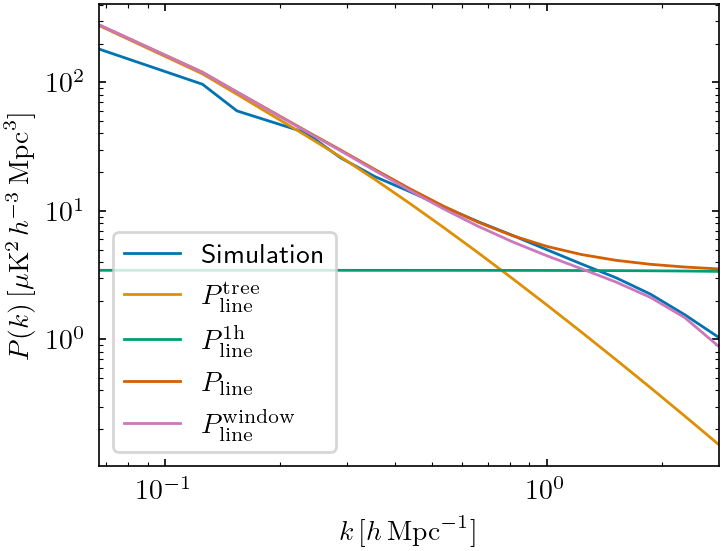

In [22]:
kpk = np.load("/home/sefa/Desktop/projects/LIM-Code/clusterdata/CII_A_438681_Response_NSUB8.npz")
k, Pk = kpk["k"], np.mean(kpk["Pkmean"], axis=0)

mask = ~np.isnan(Pk)
k, Pk = k[mask], Pk[mask]

kth = k * myastro.Mpch**-1
I11 = myastro.Thalo(1, kth, p=1, scale=(1,), beta=1)
I02 = myastro.Thalo(1, kth, p=1, scale=(2,), beta=0)

# I02 = np.ones_like(I02.value) * 3.29 * u.uK**2 * myastro.Mpch**3

plin = mycosmo.matpow(kth, 1)

color = iter(Cs)
plt.loglog(k, Pk, c=next(color), label="Simulation")
plt.loglog(k, (I11**2 * plin).to(myastro.Mpch**3 * u.uK**2), c=next(color), label=r"$P_\mathrm{line}^\mathrm{tree}$")
plt.loglog(k, (I02).to(myastro.Mpch**3 * u.uK**2), c=next(color), label=r"$P_\mathrm{line}^\mathrm{1h}$")
plt.loglog(k, (I11**2 * plin + I02).to(myastro.Mpch**3 * u.uK**2), c=next(color), label=r"$P_\mathrm{line}$")

P_TT_NL = (I11**2 * plin + I02).to(myastro.Mpch**3 * u.uK**2)
P_TT_NL_windowed = P_TT_NL * Weff_iso**2
plt.loglog(k, Weff_iso**2 * P_TT_NL, c=next(color), label=r"$P^\mathrm{window}_\mathrm{line}$")

plt.legend()
plt.xlabel("$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel("$P(k)\,[\mu \mathrm{K}^2 \,h^{-3}\,\mathrm{Mpc}^{3}]$")

# plt.savefig("output/powerspectra_CII_measurements.pdf")

In [23]:
I02.to(myastro.Mpch**3 * u.uK**2)

<Quantity [3.44429361, 3.44419945, 3.44413133, 3.44387162, 3.44363448,
           3.44327511, 3.44273055, 3.44190548, 3.44065569, 3.43876312,
           3.43589857, 3.43156596, 3.42502   , 3.41514594, 3.40028744,
           3.3780073 ] 3.2228 Mpc3 uK2>

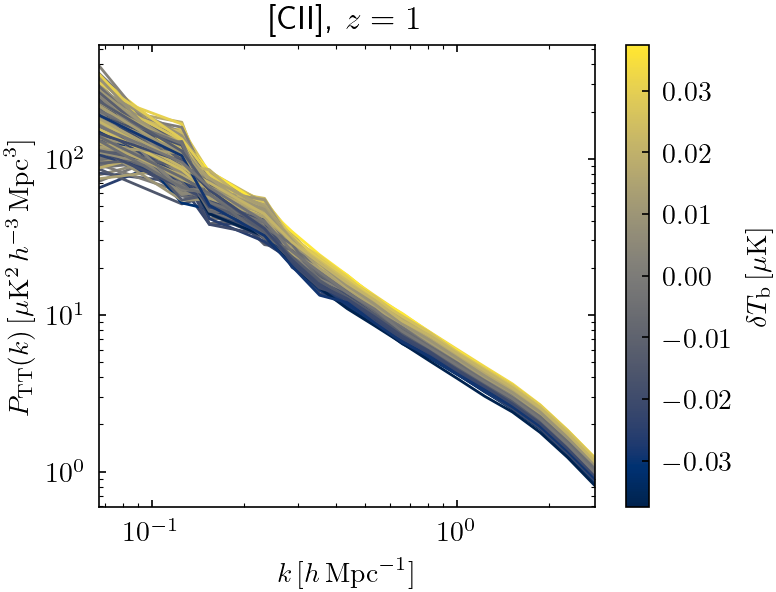

In [24]:
response8 = np.load("/home/sefa/Desktop/projects/LIM-Code/clusterdata/CII_A_438681_Response_NSUB8.npz")
dTb = response8["deltab"]

k, Pk  = response8["k"], response8["Pkmean"]

#sanitize
mask = ~np.any(np.isnan(Pk), axis=0)
k = k[mask]
Pk = Pk[:, mask]

norm = colors.Normalize(vmin=np.min(dTb), vmax=np.max(dTb))
cmap = cm.cividis
sm = cm.ScalarMappable(norm=norm, cmap=cmap)

ax = plt.subplot()

Ts = iter(dTb)
for Pki in Pk:
    plt.loglog(k, Pki, c=cmap(norm(next(Ts))))

plt.xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P_\mathrm{TT}(k)\,[\mu \mathrm{K}^2\,h^{-3}\,\mathrm{Mpc}^{3}]$")
plt.title("[CII], $z=1$")
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\delta T_\mathrm{b}\,[\mu\mathrm{K}]$")

plt.savefig("output/rawsubvolume_powerspectra_CII_measurement")

In [25]:
def get_ssl_response(pobs: spobs.PowerSpectra, kr):
    mycosmo = pobs.cosmology
    myastro = pobs.astro

    Delta = 4 * np.pi / (2 * np.pi)**3 * mycosmo.k**3 * mycosmo.matpow(mycosmo.k, 1, tracer=myastro.halomodel.tracer)
    logD = np.log(Delta.to(1).value)

    gamma = UnivariateSpline(
        np.log(
            mycosmo.k.to(u.Mpc**-1).value
        ),
        logD,
        s=0,
    ).derivative(1)(
        np.log(kr.to(u.Mpc**-1).value)
    )
    
    Pk = myastro.cosmology.matpow(kr, 1, tracer=myastro.halomodel.tracer)

    I11 = myastro.Tbavg(1, 1, 1)
    I21 = (
        myastro.Tbavg("b2sph_lazeyras", 1, 1)
        # - 4 / 3 * myastro.Thalo(1, kr, p=1, scale=(1,), beta="bG2")
    )
    
    I02 = myastro.Tbavg(0, 1, 2)
    I12 = myastro.Tbavg(1, 1, 2)
    Phalo = I11**2 * Pk + I02

    BC = (68 / 21 * I11**2 + 2 * I11 * I21) * Pk
    LD = - 1 / 3 * gamma * I11**2 * Pk
    HSV = I12
    return (BC + LD + HSV) / Phalo, Phalo

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_28626/830776013.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Bias $b^\mathrm{sph}_2$")


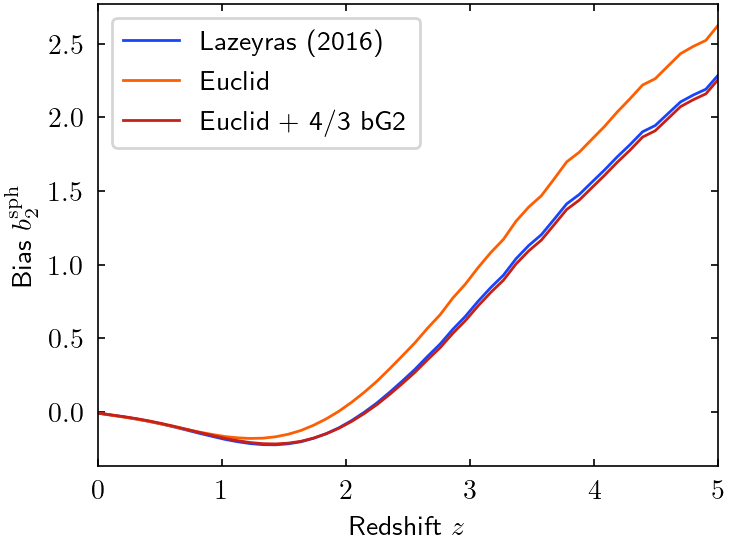

In [26]:
zgrid = np.linspace(0, 5)
b2_fabian = myastro.Tbavg("b2sph_lazeyras", zgrid, 1)
b2_azadeh = myastro.Tbavg("b2sph_euclid", zgrid, 1)
bG2 = myastro.Tbavg("bG2", zgrid, 1)

plt.plot(zgrid, b2_fabian, label="Lazeyras (2016)")
plt.plot(zgrid, b2_azadeh, label="Euclid")
plt.plot(zgrid, b2_azadeh + 4/3 * bG2, label="Euclid + 4/3 bG2")
plt.xlabel("Redshift $z$")
plt.ylabel("Bias $b^\mathrm{sph}_2$")
plt.legend()

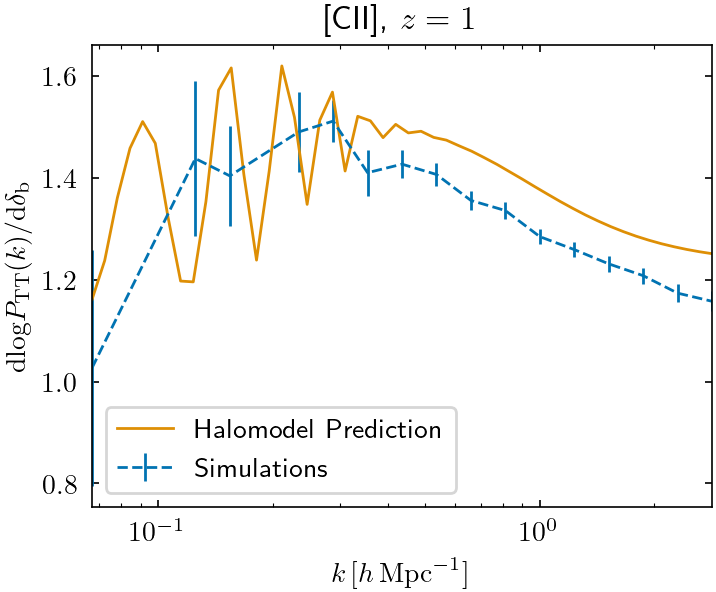

In [27]:
def linear(x, a, b):
    return a * x + b

pobs, pcov = [], []
for Pik in Pk.T:
    pi, ci = curve_fit(linear, dTb, Pik)
    pobs.append(pi)
    pcov.append(ci)
pobs = np.array(pobs)
pcov = np.array(pcov)

ai, bi = pobs[:, 0], pobs[:, 1]
ri_sims =  1.04 * 0.2284 * ai / bi
si = ri_sims * np.sqrt(pcov[:, 0, 0]/ ai**2 + pcov[:, 1, 1]/ bi**2 - 2 * bi / ai * pcov[:, 0, 1])
k_sims = k

k_ssl = np.geomspace(np.min(k_sims), np.max(k_sims)) * myastro.Mpch**-1
rssl, pssl = get_ssl_response(pobs_CII, k_ssl)

color = iter(Cs)
plt.errorbar(k, ri_sims, si, ls="--", label="Simulations", c=next(color))
plt.semilogx(k_ssl.to(myastro.Mpch**-1), rssl, label="Halomodel Prediction", c=next(color))
plt.legend()
plt.xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$\mathrm{dlog}P_\mathrm{TT}(k)/\mathrm{d}\delta_\mathrm{b}$")
plt.title("[CII], $z=1$")


plt.savefig("output/response_CII_measurement.pdf")

In [49]:
def get_ssl_response_fitted(kr, b11, b21, sn, b12):
    mycosmo = pobs_CII.cosmology
    myastro = pobs_CII.astro
    try:
        kr.unit
    except:
        kr = kr * myastro.Mpch**-1

    Delta = 4 * np.pi / (2 * np.pi)**3 * mycosmo.k**3 * mycosmo.matpow(mycosmo.k, 1, tracer=myastro.halomodel.tracer)
    logD = np.log(Delta.to(1).value)

    gamma = UnivariateSpline(
        np.log(
            mycosmo.k.to(u.Mpc**-1).value
        ),
        logD,
        s=0,
    ).derivative(1)(
        np.log(kr.to(u.Mpc**-1).value)
    )

    Pk = myastro.cosmology.matpow(kr, 1, tracer=myastro.halomodel.tracer)

    I11 = myastro.Tbavg(1, 1, 1) * b11
    I21 = myastro.Tbavg("b2sph_lazeyras", 1, 1) * b21
    I02 = myastro.Tbavg(0, 1, 2) * sn
    I12 = myastro.Tbavg(1, 1, 2) * b12

    Phalo = I11**2 * Pk + I02

    BC = (68 / 21 * I11**2 + 2 * I11 * I21) * Pk
    LD = - 1 / 3 * gamma * I11**2 * Pk
    HSV = I12
    return (BC + LD + HSV) / Phalo #, Phalo

In [50]:
k_ssl

<Quantity [0.04539647, 0.04900008, 0.05288975, 0.05708819, 0.0616199 ,
           0.06651135, 0.07179108, 0.07748992, 0.08364114, 0.09028065,
           0.09744721, 0.10518266, 0.11353215, 0.12254444, 0.13227213,
           0.14277201, 0.15410538, 0.16633841, 0.17954251, 0.19379475,
           0.20917836, 0.22578313, 0.243706  , 0.2630516 , 0.28393288,
           0.30647173, 0.33079974, 0.35705892, 0.38540259, 0.41599619,
           0.44901835, 0.48466184, 0.52313474, 0.56466165, 0.60948501,
           0.65786649, 0.71008853, 0.76645601, 0.82729798, 0.89296965,
           0.9638544 , 1.04036604, 1.12295125, 1.21209214, 1.30830913,
           1.4121639 , 1.52426276, 1.64526013, 1.77586238, 1.91683196] 1 / Mpc>

In [51]:
popt, pcov = curve_fit(get_ssl_response_fitted, k, ri_sims, [1, 1, 1, 1,], si)

/home/sefa/Desktop/projects/LIM-Code/SSC-project/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [52]:
myastro.Tbavg(1, 1, 2) / myastro.Tbavg(0, 1, 2)

<Quantity 1.23065669>

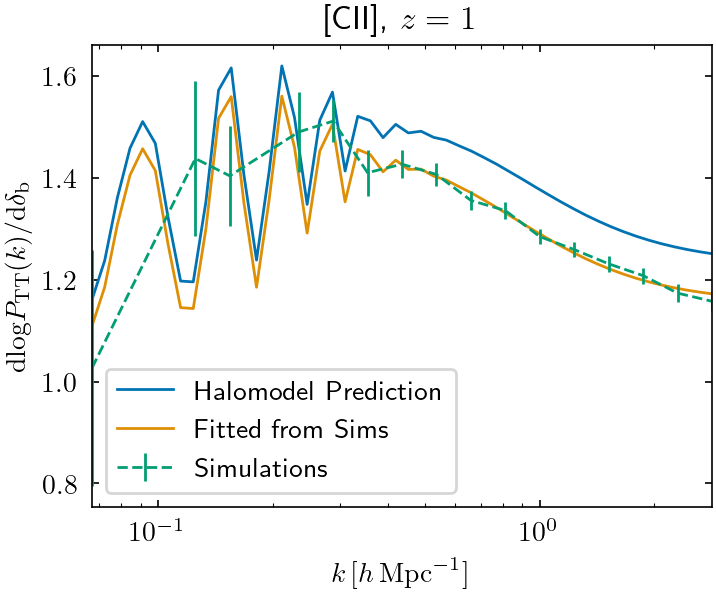

In [53]:
color = iter(Cs)

def linear(x, a, b):
    return a * x + b

pobs, pcov = [], []
for Pik in Pk.T:
    pi, ci = curve_fit(linear, dTb, Pik)
    pobs.append(pi)
    pcov.append(ci)
pobs = np.array(pobs)
pcov = np.array(pcov)

ai, bi = pobs[:, 0], pobs[:, 1]
ri_sims =  1.04 * 0.2284 * ai / bi
si = ri_sims * np.sqrt(pcov[:, 0, 0]/ ai**2 + pcov[:, 1, 1]/ bi**2 - 2 * bi / ai * pcov[:, 0, 1])
k_sims = k

k_ssl = np.geomspace(np.min(k_sims), np.max(k_sims)) * myastro.Mpch**-1

rssl, pssl = get_ssl_response(pobs_CII, k_ssl)
plt.semilogx(k_ssl.to(myastro.Mpch**-1), rssl, label="Halomodel Prediction", c=next(color))

rssl_2 = get_ssl_response_fitted(k_ssl, *popt)
plt.semilogx(k_ssl.to(myastro.Mpch**-1), rssl_2, label="Fitted from Sims", c=next(color))

plt.errorbar(k, ri_sims, si, ls="--", label="Simulations", c=next(color))
plt.legend()
plt.xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$\mathrm{dlog}P_\mathrm{TT}(k)/\mathrm{d}\delta_\mathrm{b}$")
plt.title("[CII], $z=1$")


plt.savefig("output/response_CII_measurement.pdf")

In [ ]:
from scipy.special import spherical_jn
from scipy.integrate import dblquad

def A_of_u(u, epsabs=1e-6, epsrel=1e-6):
    """
    Compute A(u) = ⟨ j0^2(u kx/2) j0^2(u ky/2) j0^2(u kz/2) ⟩ over the sphere
    using scipy.integrate.dblquad.
    """

    # integrand in φ then θ (dblquad integrates inner first)
    def integrand(phi, theta):
        # direction cosines
        kx = np.sin(theta)*np.cos(phi)
        ky = np.sin(theta)*np.sin(phi)
        kz = np.cos(theta)

        Jx = spherical_jn(0, 0.5*u*kx)
        Jy = spherical_jn(0, 0.5*u*ky)
        Jz = spherical_jn(0, 0.5*u*kz)

        return (Jx*Jy*Jz)**2 * np.sin(theta)   # include Jacobian factor

    # dblquad integrates phi from 0→2π inside, θ from 0→π outside
    res, err = dblquad(integrand, 0, np.pi, lambda t: 0, lambda t: 2*np.pi,
                       epsabs=epsabs, epsrel=epsrel)

    return res / (4*np.pi)

L = 128 * myastro.Mpch
x = np.geomspace(1e-2, 1e2)
k = x / L
A = [A_of_u(xi) for xi in x]

sigma_integrand = 4 * np.pi * k**3 * mycosmo.matpow(k, 1) * A
soverV = np.trapezoid(sigma_integrand, x=np.log(k.value)) / (2 * np.pi)**3
print(soverV)

In [40]:
pk_file = response8
f, Nsub = pk_file, 8

Pk = f["Pkmean"]
nanmask = np.any(np.isnan(Pk), axis=0)

Pk = Pk[:, ~nanmask]
k, modes = f["k"][~nanmask], f["modes"][0, ~nanmask]

mPk = np.mean(Pk, axis=0)
dPk = Pk - mPk[None, :]
cov_sub = 1 / (Nsub**3- 1) * np.einsum("il, im -> lm", dPk, dPk)

In [41]:
cov_gaussian = 2 / modes * np.diag(mPk**2)

In [42]:
ssc_sim = soverV * np.outer(ri_sims * mPk, ri_sims * mPk)

rth, Pth = get_ssl_response(pobs_CII, k * myastro.Mpch**-1)
ssc_hm = soverV * np.outer(rth * P_TT_NL_windowed, rth * P_TT_NL_windowed).to(u.uK**4 * myastro.Mpch**6).value

In [43]:
covfile_f8 = np.load("/home/sefa/Desktop/projects/LIM-Code/clusterdata/CII_A_442916_NSUB8_JK.npz")
covs = covfile_f8["Cov"]
mask = ~np.all(np.isnan(covs[0, :, :]), axis=0)
covs_masked = covs[:, np.outer(mask, mask)].reshape(512, 16, 16)
cov_small_jk = np.mean(covs_masked, axis=0)

In [44]:
corr_cov_file = np.load("/home/sefa/Desktop/projects/LIM-Code/clusterdata/CII_A_731371_NSUB8_JK_corrected.npz")
cov_corrected = corr_cov_file["Cov"]
cov_corrected = cov_corrected[:, np.outer(mask, mask)].reshape((512, 16, 16))
response = corr_cov_file["response"][mask]
cov_small_jk_corrected = cov_corrected - (64-1) * corr_cov_file["sigmadeltab"][:, None, None] * np.outer(response, response)
cov_small_jk_corrected = np.mean(cov_small_jk_corrected, axis=0)

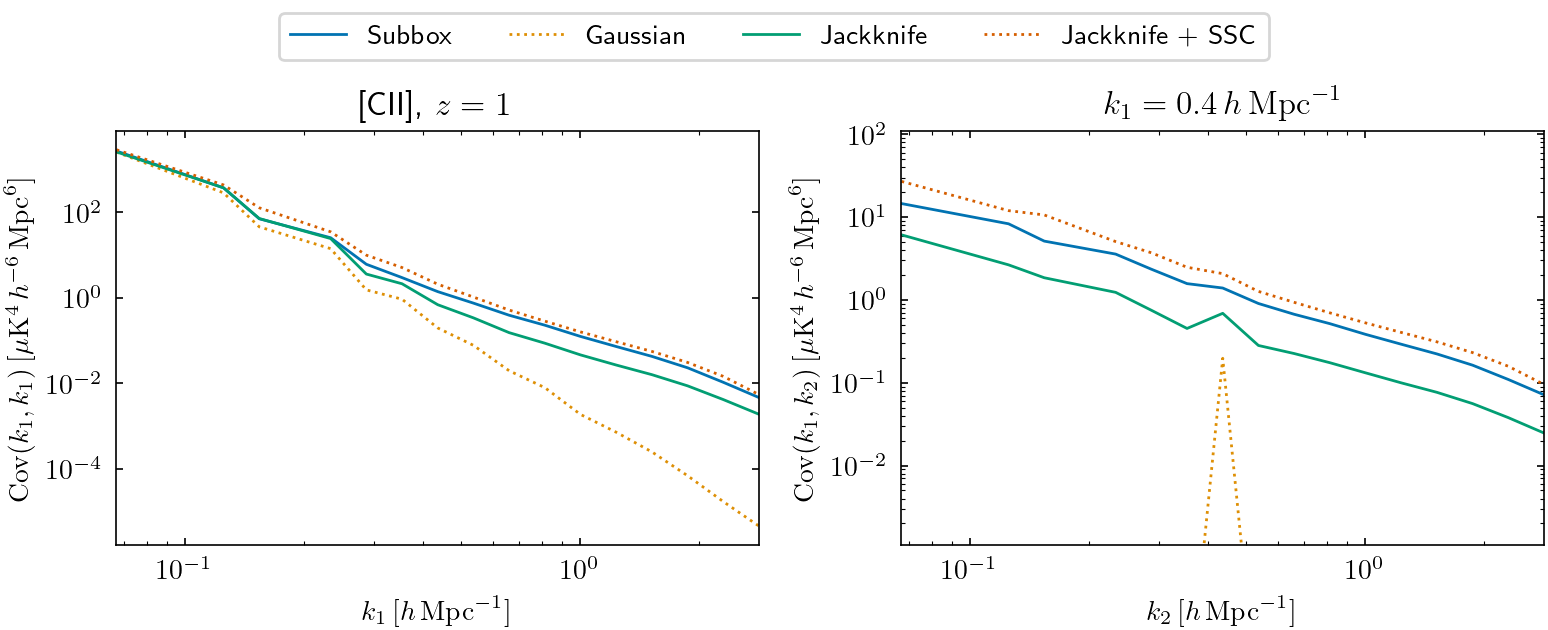

In [59]:
fw, fh=plt.rcParams['figure.figsize']
fig, axs=plt.subplots(1,2, figsize=(2*fw, 1.111*fh)) 


color = iter(Cs)
axs[0].loglog(k, np.diag(cov_sub), label="Subbox", ls="-", c=next(color))
axs[0].loglog(k, np.diag(cov_gaussian), label="Gaussian", ls=":", c=next(color))
axs[0].loglog(k, np.diag(cov_small_jk), label="Jackknife", c=next(color))
axs[0].loglog(k, np.diag(cov_small_jk + ssc_hm),  label="Jackknife + SSC", ls=":", c=next(color))

axs[0].set_xlabel(r"$k_1\,[h\,\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$\mathrm{Cov}(k_1,k_1)\,[\mu \mathrm{K}^4\,h^{-6}\,\mathrm{Mpc}^{6}]$")
axs[0].set_title(r"[CII], $z=1$")

color = iter(Cs)
axs[1].loglog(k, (cov_sub)[6, :], label="Subbox", ls="-", c=next(color))
axs[1].loglog(k, (cov_gaussian + 1e-5)[6, :], label="Gaussian", ls=":", c=next(color))
axs[1].loglog(k, (cov_small_jk)[6, :], label="Jackknife", c=next(color))
axs[1].loglog(k, (cov_small_jk + ssc_hm)[6, :],  label="Jackknife + SSC", ls=":", c=next(color))



axs[1].set_xlabel(r"$k_2\,[h\,\mathrm{Mpc}^{-1}]$")
axs[1].set_ylabel(r"$\mathrm{Cov}(k_1,k_2)\,[\mu \mathrm{K}^4\,h^{-6}\,\mathrm{Mpc}^{6}]$")
axs[1].set_ylim(1.1e-3, 1.1e2)
axs[1].set_title(r"$k_1=0.4\,h\,\mathrm{Mpc}^{-1}$")

handles, labels = [], []

for ax in [fig.axes[0]]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(handles, labels, loc='upper center', ncol=4)
# plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.9])  # <-- reduce top area for legend
# plt.savefig("output/covariance_both_CII.pdf")

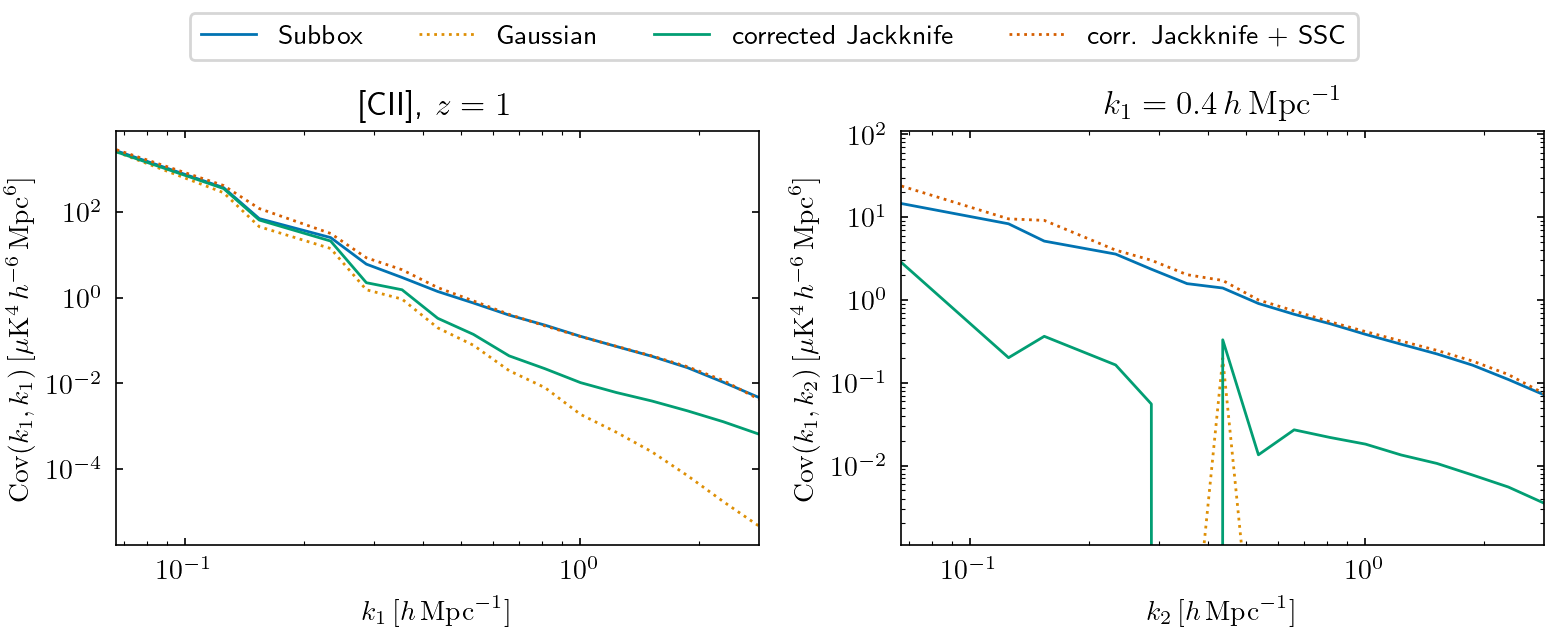

In [60]:
fw, fh=plt.rcParams['figure.figsize']
fig, axs=plt.subplots(1,2, figsize=(2*fw, 1.111*fh)) 


color = iter(Cs)
axs[0].loglog(k, np.diag(cov_sub), label="Subbox", ls="-", c=next(color))
axs[0].loglog(k, np.diag(cov_gaussian), label="Gaussian", ls=":", c=next(color))
axs[0].loglog(k, np.diag(cov_small_jk_corrected), label="corrected Jackknife", c=next(color))
axs[0].loglog(k, np.diag(cov_small_jk_corrected + ssc_hm),  label="corr. Jackknife + SSC", ls=":", c=next(color))

axs[0].set_xlabel(r"$k_1\,[h\,\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$\mathrm{Cov}(k_1,k_1)\,[\mu \mathrm{K}^4\,h^{-6}\,\mathrm{Mpc}^{6}]$")
axs[0].set_title(r"[CII], $z=1$")

color = iter(Cs)
axs[1].loglog(k, (cov_sub)[6, :], label="Subbox", ls="-", c=next(color))
axs[1].loglog(k, (cov_gaussian + 1e-5)[6, :], label="Gaussian", ls=":", c=next(color))
axs[1].loglog(k, (cov_small_jk_corrected)[6, :], label="corrected Jackknife", c=next(color))
axs[1].loglog(k, (cov_small_jk_corrected + ssc_hm)[6, :],  label="corr. Jackknife + SSC", ls=":", c=next(color))


axs[1].set_xlabel(r"$k_2\,[h\,\mathrm{Mpc}^{-1}]$")
axs[1].set_ylabel(r"$\mathrm{Cov}(k_1,k_2)\,[\mu \mathrm{K}^4\,h^{-6}\,\mathrm{Mpc}^{6}]$")
axs[1].set_ylim(1.1e-3, 1.1e2)
axs[1].set_title(r"$k_1=0.4\,h\,\mathrm{Mpc}^{-1}$")

handles, labels = [], []

for ax in [fig.axes[0]]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

fig.legend(handles, labels, loc='upper center', ncol=4)
# plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.9])  # <-- reduce top area for legend
# plt.savefig("output/covariance_both_CII.pdf")